In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import os
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)

1.14.0


In [5]:
def reset_seed(seed=42):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.set_random_seed(seed)

### 载入数据

In [6]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20250624_code.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1830 entries, 0 to 1829
Columns: 323 entries, Unnamed: 0 to Y
dtypes: float64(18), int64(303), object(2)
memory usage: 4.5+ MB


array(['芨芨草草原', '针茅属荒漠草原', '紫花针茅草原', '猪毛菜属荒漠', '高山绢蒿荒漠', '蒿属荒漠', '合头草荒漠',
       '枇杷柴荒漠', '新疆银穗草草原', '旱蒿荒漠', '新疆银穗草、穗状寒生羊茅荒漠草原', '绢蒿属荒漠', '驼绒藜荒漠',
       '羊茅属草原', '羊茅属、杂类草草甸草原', '针茅属高寒草原', '小针茅荒漠草原', '早熟禾属草甸', '芨芨草草甸',
       '农田', '盐生草荒漠', '果园', '裸地', '人工林', '含盐生半灌木的芦苇盐生草甸', '多枝柽柳荒漠',
       '疏叶骆驼刺盐生草甸', '芦苇草甸', '沙拐枣属荒漠', '柽柳属灌丛', '红砂荒漠', '麻黄荒漠', '镰芒针茅荒漠草原',
       '锦鸡儿属荒漠', '柽柳属荒漠', '芦苇盐生草甸', '梭梭荒漠', '芦苇荒漠', '膜果麻黄荒漠', '冷蒿荒漠草原',
       '胡杨荒漠', '花花柴盐生草甸', '骆驼刺荒漠', '霸王荒漠', '假木贼属荒漠', '锦鸡儿荒漠草原', '盐爪爪荒漠',
       '盐穗木荒漠', '薹草属草甸', '针茅属草原', '锦鸡儿属灌丛', '线叶嵩草草甸', '嵩草属草甸', '高山嵩草高寒草甸',
       '草原薹草、杂类草草甸草原', '戈壁藜荒漠', '沙生针茅荒漠草原', '鸭茅草甸', '粗毛锦鸡儿荒漠', '芨芨草荒漠草原',
       '冷蒿荒漠', '藜科荒漠', '小蓬荒漠', '盐生假木贼荒漠', '白茎绢蒿荒漠'], dtype=object)

In [7]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

农田                  279
裸地                   99
芦苇草甸                 92
果园                   63
梭梭荒漠                 62
针茅属草原                60
蒿属荒漠                 57
薹草属草甸                56
紫花针茅草原               49
含盐生半灌木的芦苇盐生草甸        46
驼绒藜荒漠                42
多枝柽柳荒漠               40
猪毛菜属荒漠               38
人工林                  37
疏叶骆驼刺盐生草甸            33
枇杷柴荒漠                31
芦苇盐生草甸               30
针茅属荒漠草原              26
旱蒿荒漠                 26
盐生假木贼荒漠              26
假木贼属荒漠               24
线叶嵩草草甸               23
花花柴盐生草甸              21
芦苇荒漠                 21
早熟禾属草甸               21
麻黄荒漠                 20
绢蒿属荒漠                20
羊茅属草原                19
嵩草属草甸                19
高山绢蒿荒漠               19
膜果麻黄荒漠               19
白茎绢蒿荒漠               18
红砂荒漠                 18
戈壁藜荒漠                18
柽柳属荒漠                18
芨芨草草原                17
柽柳属灌丛                17
针茅属高寒草原              17
沙拐枣属荒漠               16
合头草荒漠                16
镰芒针茅荒漠草原             15
骆驼刺荒漠           

In [8]:
data_train.head()

,Unnamed: 0,Index,system:index,num,className,Eng,aet2020,aet2021,aet2101,aet2102,...,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,0,0,00000000000000000000_0,0,芨芨草草原,NaN,11.833333,12.0,0,11,...,3223,2128,3183,1118,1765,3418,3360,2847,79.925086,36.288893
1,1,1,00000000000000000001_0,1,针茅属荒漠草原,NaN,11.833333,12.0,0,11,...,2388,1616,2825,936,1396,2947,2755,2223,79.921403,36.306444
2,2,2,00000000000000000002_0,1,针茅属荒漠草原,NaN,11.833333,12.0,0,0,...,3320,2222,3327,1253,1935,3868,3946,3290,79.881782,36.252338
3,3,3,00000000000000000003_0,2,紫花针茅草原,NaN,11.833333,12.0,0,0,...,1486,874,3172,501,916,3475,2609,1442,79.810183,36.286247
4,4,4,00000000000000000004_0,3,猪毛菜属荒漠,NaN,11.833333,12.0,0,11,...,3124,1958,2895,1101,1623,3176,3215,2822,79.911481,36.304447


In [9]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [10]:
num_classes = data_train['num'].nunique()
print(num_classes)

65


### 切分数据集（已经提前切分的话不用此部分）

In [11]:
split_index = int(len(data_all)*0.8)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 366 entries, 1711 to 184
Columns: 323 entries, Unnamed: 0 to Y
dtypes: float64(18), int64(303), object(2)
memory usage: 926.4+ KB


In [12]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,6:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,6:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(         aet2020     aet2021  aet2101  aet2102  aet2103  aet2104  aet2105  \
 1694  205.416670  194.666670        0        0       16      697      255   
 993   180.833330  159.416670        0        0       26      837      601   
 475    30.666666   34.583332        0       12       44        5       66   
 437    45.750000   70.583336        0       41       17      123       16   
 1503  232.333330  235.000000        0        0        0      854      449   
 
       aet2106  aet2107  aet2108  ...  SR230821b07  SR230829b01  SR230829b02  \
 1694      377      141      242  ...         2678         1027         2004   
 993       584      526      448  ...         1824          852         2854   
 475         8        9        9  ...         3444         2982         3133   
 437       244       95       21  ...         1563         1257         3279   
 1503      632      413      334  ...         2778         1253         2676   
 
       SR230829b03  SR230829b04  SR230829b05  SR

### 顺序编码转独热编码

In [13]:
train_y = tf.keras.utils.to_categorical(train_y)

In [14]:
pd.set_option('display.max_columns', None)
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [15]:
train_y.shape[1]

65

In [16]:
dim_num = train_x.shape[1]
print(dim_num)

317


### 定义损失函数为Focal Loss

In [17]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [19]:
reset_seed()
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1024,input_dim=dim_num))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.2))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.01, patience=20, mode='auto')
model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1024)              325632    
_________________________________________________________________
batch_normalization (BatchNo (None, 1024)              4096      
_________________________________________________________________
dense_1 (Dense)              (None, 512)               524800    
_________________________________________________________________
batch_normalization_1 (Batch (None, 512)               2048      
_________________________________________________________________
dense_2 (Dense)              (None, 256)               131328    
_________________________________________________________________
batch_normalization_2 (Batch (None, 256)               1024      
_________________________________________________________________
dense_3 (Dense)              (None, 128)               3

### 开始训练

In [20]:
e = 350
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=64,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/350
1464/1464 [==============================] - 1s 833us/sample - loss: 1.2164 - acc: 0.1660
Epoch 2/350
1464/1464 [==============================] - 0s 88us/sample - loss: 0.4479 - acc: 0.2814
Epoch 3/350
1464/1464 [==============================] - 0s 83us/sample - loss: 0.1641 - acc: 0.2766
Epoch 4/350
1464/1464 [==============================] - 0s 82us/sample - loss: 0.0695 - acc: 0.2725
Epoch 5/350
1464/1464 [==============================] - 0s 79us/sample - loss: 0.0367 - acc: 0.2766
Epoch 6/350
1464/1464 [==============================] - 0s 91us/sample - loss: 0.0237 - acc: 0.2691
Epoch 7/350
1464/1464 [==============================] - 0s 80us/sample - loss: 0.0180 - acc: 0.2910
Epoch 8/350
1464/1464 [==============================] - 0s 84us/sample - loss: 0.0152 - acc: 0.2883
Epoch 9/350
1464/1464 [==============================] - 0s 86us/sample - loss: 0.0137 - acc: 0.2

1464/1464 [==============================] - 0s 87us/sample - loss: 0.0105 - acc: 0.3689
Epoch 78/350
1464/1464 [==============================] - 0s 86us/sample - loss: 0.0105 - acc: 0.3579
Epoch 79/350
1464/1464 [==============================] - 0s 96us/sample - loss: 0.0108 - acc: 0.3689
Epoch 80/350
1464/1464 [==============================] - 0s 93us/sample - loss: 0.0106 - acc: 0.3518
Epoch 81/350
1464/1464 [==============================] - 0s 127us/sample - loss: 0.0107 - acc: 0.3805
Epoch 82/350
1464/1464 [==============================] - 0s 90us/sample - loss: 0.0101 - acc: 0.4071
Epoch 83/350
1464/1464 [==============================] - 0s 97us/sample - loss: 0.0096 - acc: 0.4351
Epoch 84/350
1464/1464 [==============================] - 0s 87us/sample - loss: 0.0093 - acc: 0.4344
Epoch 85/350
1464/1464 [==============================] - 0s 88us/sample - loss: 0.0091 - acc: 0.4556
Epoch 86/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.0089 - acc:

1464/1464 [==============================] - 0s 98us/sample - loss: 0.0043 - acc: 0.7008
Epoch 157/350
1464/1464 [==============================] - 0s 90us/sample - loss: 0.0042 - acc: 0.7213
Epoch 158/350
1464/1464 [==============================] - 0s 93us/sample - loss: 0.0042 - acc: 0.7234
Epoch 159/350
1464/1464 [==============================] - 0s 88us/sample - loss: 0.0042 - acc: 0.7206
Epoch 160/350
1464/1464 [==============================] - 0s 87us/sample - loss: 0.0041 - acc: 0.7357
Epoch 161/350
1464/1464 [==============================] - 0s 92us/sample - loss: 0.0041 - acc: 0.7404
Epoch 162/350
1464/1464 [==============================] - 0s 94us/sample - loss: 0.0042 - acc: 0.7404
Epoch 163/350
1464/1464 [==============================] - 0s 91us/sample - loss: 0.0041 - acc: 0.7398
Epoch 164/350
1464/1464 [==============================] - 0s 96us/sample - loss: 0.0041 - acc: 0.7432
Epoch 165/350
1464/1464 [==============================] - 0s 91us/sample - loss: 0.004

1464/1464 [==============================] - 0s 89us/sample - loss: 0.0025 - acc: 0.9296
Epoch 236/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.0025 - acc: 0.9098
Epoch 237/350
1464/1464 [==============================] - 0s 92us/sample - loss: 0.0026 - acc: 0.9214
Epoch 238/350
1464/1464 [==============================] - 0s 81us/sample - loss: 0.0026 - acc: 0.9180
Epoch 239/350
1464/1464 [==============================] - 0s 83us/sample - loss: 0.0025 - acc: 0.9092
Epoch 240/350
1464/1464 [==============================] - 0s 88us/sample - loss: 0.0025 - acc: 0.9146
Epoch 241/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.0025 - acc: 0.9180
Epoch 242/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.0025 - acc: 0.9194
Epoch 243/350
1464/1464 [==============================] - 0s 87us/sample - loss: 0.0025 - acc: 0.9092
Epoch 244/350
1464/1464 [==============================] - 0s 94us/sample - loss: 0.002

1464/1464 [==============================] - 0s 92us/sample - loss: 0.0018 - acc: 0.9761
Epoch 315/350
1464/1464 [==============================] - 0s 88us/sample - loss: 0.0019 - acc: 0.9699
Epoch 316/350
1464/1464 [==============================] - 0s 90us/sample - loss: 0.0019 - acc: 0.9631
Epoch 317/350
1464/1464 [==============================] - 0s 94us/sample - loss: 0.0019 - acc: 0.9713
Epoch 318/350
1464/1464 [==============================] - 0s 95us/sample - loss: 0.0018 - acc: 0.9761
Epoch 319/350
1464/1464 [==============================] - 0s 92us/sample - loss: 0.0018 - acc: 0.9686
Epoch 320/350
1464/1464 [==============================] - 0s 93us/sample - loss: 0.0018 - acc: 0.9740
Epoch 321/350
1464/1464 [==============================] - 0s 87us/sample - loss: 0.0018 - acc: 0.9706
Epoch 322/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.0019 - acc: 0.9727
Epoch 323/350
1464/1464 [==============================] - 0s 89us/sample - loss: 0.001

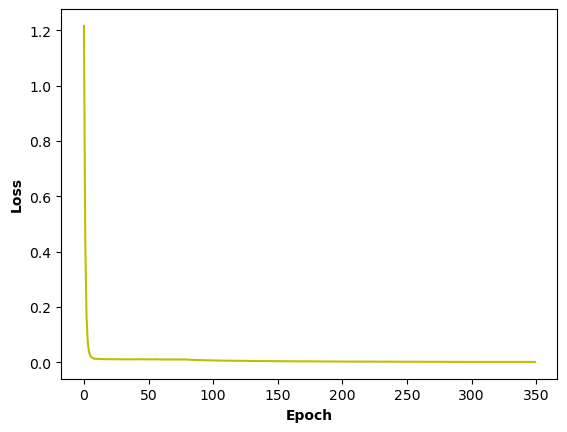

In [21]:
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.plot(range(e),history.history.get('loss'),color =  'y')
#plt.savefig('XJloss20250526.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

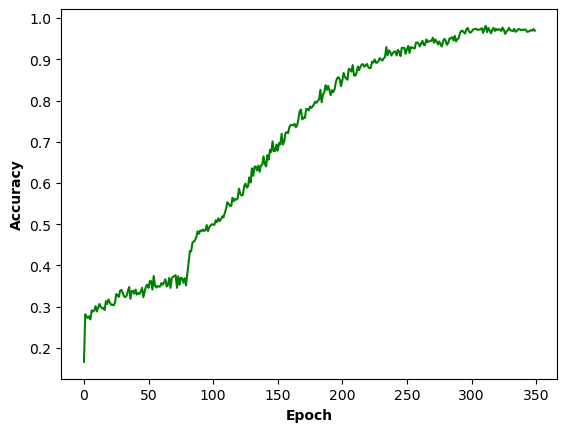

In [22]:
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.plot(range(e),history.history.get('acc'),color =  'g')
#plt.savefig('XJacc20250526.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

### 计算准确率

In [23]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
# Accuracy
acc = accuracy_score(test_y, test_r)

# Precision, Recall, F1 (macro平均适用于多分类)
precision = precision_score(test_y, test_r, average='macro')
recall = recall_score(test_y, test_r, average='macro')
f1 = f1_score(test_y, test_r, average='macro')

# Confusion Matrix
cm = confusion_matrix(test_y, test_r)

print("Accuracy:", acc)
print("Precision (macro):", precision)
print("Recall (macro):", recall)
print("F1 Score (macro):", f1)
print("Confusion Matrix:\n", cm)

366/366 [==============================] - 0s 209us/sample
Accuracy: 0.3442622950819672
Precision (macro): 0.20013274099853723
Recall (macro): 0.20338983825342183
F1 Score (macro): 0.1840060689712406
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [2 0 0 ... 0 0 0]
 [0 0 4 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 2 0]]


D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 各类别准确率

In [24]:
# 创建 num 到 className 的映射（取 data_train 中唯一的映射关系）
num_to_name = data_train.drop_duplicates(subset='num').set_index('num')['className'].to_dict()

# 每类准确率 = 对角线元素 / 该类总数（行和）
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# 每类样本数量（即该类在混淆矩阵中的行和）
per_class_count = cm.sum(axis=1)

# 输出每个类别的名称、准确率和样本数量
print("每个类别的准确率和样本数量：")
for i in sorted(num_to_name.keys()):
    name = num_to_name[i]
    acc = per_class_accuracy[i]
    count = per_class_count[i]
    print(f"{name}: acc: {acc:.2%}，count: {count}")

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """


每个类别的准确率和样本数量：
芨芨草草原: acc: 0.00%，count: 2
针茅属荒漠草原: acc: 0.00%，count: 3
紫花针茅草原: acc: 36.36%，count: 11
猪毛菜属荒漠: acc: 16.67%，count: 12
高山绢蒿荒漠: acc: 66.67%，count: 3
蒿属荒漠: acc: 33.33%，count: 15
合头草荒漠: acc: 25.00%，count: 4
枇杷柴荒漠: acc: 0.00%，count: 7
新疆银穗草草原: acc: 0.00%，count: 3
旱蒿荒漠: acc: 83.33%，count: 6
新疆银穗草、穗状寒生羊茅荒漠草原: acc: nan%，count: 0
绢蒿属荒漠: acc: 50.00%，count: 4
驼绒藜荒漠: acc: 42.86%，count: 7
羊茅属草原: acc: 0.00%，count: 3
羊茅属、杂类草草甸草原: acc: 0.00%，count: 4
针茅属高寒草原: acc: 0.00%，count: 5
小针茅荒漠草原: acc: 50.00%，count: 2
早熟禾属草甸: acc: 40.00%，count: 5
芨芨草草甸: acc: 0.00%，count: 1
农田: acc: 76.36%，count: 55
盐生草荒漠: acc: 0.00%，count: 1
果园: acc: 28.57%，count: 14
裸地: acc: 70.59%，count: 17
人工林: acc: 0.00%，count: 6
含盐生半灌木的芦苇盐生草甸: acc: 11.11%，count: 9
多枝柽柳荒漠: acc: 0.00%，count: 8
疏叶骆驼刺盐生草甸: acc: 9.09%，count: 11
芦苇草甸: acc: 36.84%，count: 19
沙拐枣属荒漠: acc: 0.00%，count: 5
柽柳属灌丛: acc: 50.00%，count: 2
红砂荒漠: acc: 0.00%，count: 7
麻黄荒漠: acc: 25.00%，count: 4
镰芒针茅荒漠草原: acc: 33.33%，count: 6
锦鸡儿属荒漠: acc: 0.00%，count: 3
柽柳属荒漠: acc:

IndexError: index 64 is out of bounds for axis 0 with size 64

In [25]:
# 转成 DataFrame，方便处理
df_test = pd.DataFrame({
    'num': test_y.iloc[:, 0].values,    # 从 DataFrame 中取出标签列
    'pred': test_r.flatten()            # 如果 test_r 是 numpy array
})

# 读入 num 到 植被型 的映射表
map_df = pd.read_csv('F:/TensorFlow/xinjiang/新疆20240718所有类别.csv', header=0, encoding='utf_8')  # 包含列：num，植被型

# 添加真实大类列
df_test = df_test.merge(map_df[['num', '植被型']], on='num', how='left')
df_test = df_test.rename(columns={'植被型': '真实植被型'})

# 添加预测大类列（通过预测的 pred 映射）
df_test = df_test.merge(map_df[['num', '植被型']], left_on='pred', right_on='num', how='left')
df_test = df_test.rename(columns={'植被型': '预测植被型'})
df_test = df_test.drop(columns=['num_y'])  # 删除多余列
df_test = df_test.rename(columns={'num_x': 'num'})  # 恢复 num

# 🧼【修正部分】：去掉包含 NaN 的行并转换为字符串
df_eval = df_test.dropna(subset=['真实植被型', '预测植被型']).copy()
y_true_big = df_eval['真实植被型'].astype(str)
y_pred_big = df_eval['预测植被型'].astype(str)

# ✅ 计算评估指标
acc = accuracy_score(y_true_big, y_pred_big)
precision = precision_score(y_true_big, y_pred_big, average='macro')
recall = recall_score(y_true_big, y_pred_big, average='macro')
f1 = f1_score(y_true_big, y_pred_big, average='macro')

# ✅ 混淆矩阵（确保标签一致顺序）
labels = sorted(y_true_big.unique())
conf_mat = confusion_matrix(y_true_big, y_pred_big, labels=labels)

# ✅ 输出
print(f"【大类层级总体指标】")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

【大类层级总体指标】
Accuracy : 0.4863
Precision: 0.3689
Recall   : 0.4041
F1 Score : 0.3672


D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [26]:
print(f"\n被排除的样本数（含NaN大类）: {len(df_test) - len(df_eval)}")


被排除的样本数（含NaN大类）: 0


In [27]:
# 统计每个植被型的测试数量和准确数
summary = (
    df_test
    .groupby('真实植被型')
    .agg(
        测试数量=('真实植被型', 'count'),
        正确数量=('预测植被型', lambda x: (x == df_test.loc[x.index, '真实植被型']).sum())
    )
    .assign(准确率=lambda df: df['正确数量'] / df['测试数量'])
    .sort_values('测试数量', ascending=False)
)

# 输出
print(summary.reset_index().to_string(index=False))

   真实植被型  测试数量  正确数量      准确率
半灌木与草本荒漠   116    52 0.448276
   半灌木草甸    78    55 0.705128
  丛生草类草原    67    35 0.522388
  根茎草类草甸    28    10 0.357143
  丛生草类草甸    24     5 0.208333
      裸地    17    12 0.705882
半乔木与灌木荒漠    15     2 0.133333
   半灌木草原    11     3 0.272727
  落叶阔叶灌丛     5     2 0.400000
  根茎草类草原     2     1 0.500000
    人工草地     1     0 0.000000
   杂类草草原     1     1 1.000000
   杂类草草甸     1     0 0.000000
